# NB06 — 공영주차장 후보지 전처리

## 목적

이 노트북은 성남시 내 **공영주차장**을 드론 허브/버티포트 후보지로 전처리합니다.

### 왜 공영주차장인가?

| 이유 | 설명 |
|------|------|
| 공공 소유·운영 | 민간 부지 대비 협의·배치 조율이 용이 |
| 차량 접근성 기반시설 | 이미 포장·개방된 공간 — 인프라 추가 비용 최소화 |
| 주차면수 = 면적 프록시 | 면수가 많을수록 물리적 여유 공간이 클 가능성 |
| 이용률/회전율 | 포화도가 낮은 주차장이 허브 용도로 공간을 제공하기 유리 |
| 좌표 데이터 | 수요·경사·건물·경계 레이어와 직접 결합 가능 |

## 입력 데이터

- `00_data/경기도_성남시_주차장정보_20251226.csv` — 주차장 마스터 (172개)
- `00_data/경기도 성남시_공영주차장 월별 입출차 현황_20251210.csv` — 월별 입출차 (2023~2025)
- `processed/seongnam_boundary.gpkg` — 성남시 행정경계

## 출력 데이터

- `processed/parking_candidates.gpkg`
- `processed/parking_candidates.parquet`
- `processed/parking_usage_merge_diagnostics.csv`
- `processed/parking_candidates_map.html` (선택)


In [1]:
from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 60)

# ── Paths ────────────────────────────────────────────────
HERE = Path.cwd()                         # 01_preprocessing/
BASE = HERE.parent                        # project root
DATA = BASE / '00_data'
PROC = BASE / 'processed'
PROC.mkdir(exist_ok=True)

MASTER_CSV = DATA / '경기도_성남시_주차장정보_20251226.csv'
USAGE_CSV  = DATA / '경기도 성남시_공영주차장 월별 입출차 현황_20251210.csv'
BOUNDARY   = PROC / 'seongnam_boundary.gpkg'

print('BASE:', BASE)
for p in [MASTER_CSV, USAGE_CSV, BOUNDARY]:
    print(f'  {p.name}: {"OK" if p.exists() else "MISSING"}')

BASE: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset
  경기도_성남시_주차장정보_20251226.csv: OK
  경기도 성남시_공영주차장 월별 입출차 현황_20251210.csv: OK
  seongnam_boundary.gpkg: OK


## 1. 주차장 마스터 로드

In [2]:
KEEP_COLS_RAW = [
    '주차장관리번호', '주차장명', '주차장구분', '주차장유형',
    '소재지도로명주소', '소재지지번주소',
    '주차구획수', '운영요일',
    '평일운영시작시각', '평일운영종료시각',
    '토요일운영시작시각', '토요일운영종료시각',
    '공휴일운영시작시각', '공휴일운영종료시각',
    '요금정보', '관리기관명',
    '위도', '경도',
    '장애인전용주차구역보유여부', '데이터기준일자',
]

RENAME_MAP = {
    '주차장관리번호':       'lot_id',
    '주차장명':             'lot_name',
    '주차장구분':           'lot_class',
    '주차장유형':           'lot_subtype',
    '소재지도로명주소':     'address_road',
    '소재지지번주소':       'address_jibun',
    '주차구획수':           'capacity_raw',
    '운영요일':             'op_days',
    '평일운영시작시각':     'op_wday_start',
    '평일운영종료시각':     'op_wday_end',
    '토요일운영시작시각':   'op_sat_start',
    '토요일운영종료시각':   'op_sat_end',
    '공휴일운영시작시각':   'op_hol_start',
    '공휴일운영종료시각':   'op_hol_end',
    '요금정보':             'fee_info',
    '관리기관명':           'operator',
    '위도':                 'lat',
    '경도':                 'lon',
    '장애인전용주차구역보유여부': 'has_disabled_spaces',
    '데이터기준일자':       'data_date',
}

df_master = pd.read_csv(MASTER_CSV, encoding='utf-8-sig')
print(f'원본 columns ({len(df_master.columns)}개):', list(df_master.columns))
print(f'원본 rows: {len(df_master):,}')

# Keep only available columns (some optional cols may be absent)
available = [c for c in KEEP_COLS_RAW if c in df_master.columns]
df_master = df_master[available].rename(columns=RENAME_MAP)

print(f'\n정제 후 columns ({len(df_master.columns)}개):', list(df_master.columns))
df_master.head(3)

원본 columns (32개): ['주차장관리번호', '주차장명', '주차장구분', '주차장유형', '소재지도로명주소', '소재지지번주소', '주차구획수', '급지구분', '부제시행구분', '운영요일', '평일운영시작시각', '평일운영종료시각', '토요일운영시작시각', '토요일운영종료시각', '공휴일운영시작시각', '공휴일운영종료시각', '요금정보', '주차기본시간', '주차기본요금', '추가단위시간', '추가단위요금', '1일주차권요금적용시간', '1일주차권요금', '월정기권요금', '결제방법', '특기사항', '관리기관명', '전화번호', '위도', '경도', '장애인전용주차구역보유여부', '데이터기준일자']
원본 rows: 172

정제 후 columns (20개): ['lot_id', 'lot_name', 'lot_class', 'lot_subtype', 'address_road', 'address_jibun', 'capacity_raw', 'op_days', 'op_wday_start', 'op_wday_end', 'op_sat_start', 'op_sat_end', 'op_hol_start', 'op_hol_end', 'fee_info', 'operator', 'lat', 'lon', 'has_disabled_spaces', 'data_date']


,lot_id,lot_name,lot_class,lot_subtype,address_road,address_jibun,capacity_raw,op_days,op_wday_start,op_wday_end,op_sat_start,op_sat_end,op_hol_start,op_hol_end,fee_info,operator,lat,lon,has_disabled_spaces,data_date
0,204-1-000001,수상4,공영,노상,경기도 성남시 수정구 산성대로 415,NaN,14,평일,09:00,18:00,00:00,00:00,00:00,00:00,혼합,성남도시개발공사 노상주차처,37.449054,127.158354,NaN,2025-12-26
1,204-1-000002,수상5,공영,노상,경기도 성남시 수정구 산성대로 395,NaN,17,평일,09:00,18:00,00:00,00:00,00:00,00:00,혼합,성남도시개발공사 노상주차처,37.447459,127.157645,NaN,2025-12-26
2,204-1-000003,수상7,공영,노상,경기도 성남시 수정구 산성대로 285,NaN,14,평일,09:00,18:00,00:00,00:00,00:00,00:00,혼합,성남도시개발공사 노상주차처,37.441664,127.148493,NaN,2025-12-26


## 2. 기하 생성 및 성남시 경계 검증

In [3]:
# ── Numeric lat/lon ──────────────────────────────────────
df_master['lat'] = pd.to_numeric(df_master['lat'], errors='coerce')
df_master['lon'] = pd.to_numeric(df_master['lon'], errors='coerce')

# ── Seongnam plausible bounds (EPSG:4326) ────────────────
LAT_MIN, LAT_MAX = 37.30, 37.55
LON_MIN, LON_MAX = 127.05, 127.25

df_master['valid_coords'] = (
    df_master['lat'].notna() &
    df_master['lon'].notna() &
    df_master['lat'].between(LAT_MIN, LAT_MAX) &
    df_master['lon'].between(LON_MIN, LON_MAX)
)

print(f'좌표 유효: {df_master["valid_coords"].sum()} / {len(df_master)}')

# ── Load boundary ────────────────────────────────────────
boundary = gpd.read_file(BOUNDARY, layer='city').to_crs(4326)
city_poly = boundary.union_all()  # single polygon/multipolygon
print('경계 CRS:', boundary.crs)

# ── Build GeoDataFrame for valid-coord rows ───────────────
valid_mask = df_master['valid_coords']

geoms = df_master.loc[valid_mask].apply(
    lambda r: Point(r['lon'], r['lat']), axis=1
)
gdf = gpd.GeoDataFrame(df_master.loc[valid_mask].copy(),
                        geometry=geoms, crs='EPSG:4326')

# Rows with invalid coords go to diagnostics
df_invalid_coords = df_master.loc[~valid_mask].copy()
df_invalid_coords['drop_reason'] = 'invalid_coords'

# ── Boundary containment check ────────────────────────────
gdf['within_boundary'] = gdf.geometry.within(city_poly)
print(f'경계 내 포함: {gdf["within_boundary"].sum()} / {len(gdf)}')

# Outside boundary → diagnostics
df_outside = gdf.loc[~gdf['within_boundary']].drop(columns='geometry').copy()
df_outside['drop_reason'] = 'outside_boundary'

# Final valid candidates (coord + boundary)
gdf_valid = gdf.loc[gdf['within_boundary']].copy()
print(f'\n최종 유효 후보지: {len(gdf_valid)}개')

좌표 유효: 172 / 172
경계 CRS: EPSG:4326
경계 내 포함: 172 / 172

최종 유효 후보지: 172개


## 3. 월별 입출차 현황 로드

- 2023·2024·2025 세 개 연도를 포함
- 2025년 12월은 데이터 수집일(2025-12-10) 이전이라 미완성 → `NaN` 처리 후 평균 계산에서 제외
- 결측값을 0으로 처리하지 않음

In [4]:
df_usage_raw = pd.read_csv(USAGE_CSV, encoding='utf-8-sig')
df_usage_raw.columns = df_usage_raw.columns.str.strip()

print('원본 shape:', df_usage_raw.shape)
print('columns:', list(df_usage_raw.columns))
print('연도 분포:')
print(df_usage_raw['연도'].value_counts().sort_index())

원본 shape: (529, 14)
columns: ['주차장명', '연도', '1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
연도 분포:
연도
2023    176
2024    175
2025    178
Name: count, dtype: int64


In [5]:
# ── Identify month columns robustly ──────────────────────
MONTH_PAT = re.compile(r'^(\d{1,2})월$')
month_cols = [c for c in df_usage_raw.columns if MONTH_PAT.match(c)]
month_nums = {c: int(MONTH_PAT.match(c).group(1)) for c in month_cols}
print('월 컬럼:', month_cols)

# ── Filter to valid years ─────────────────────────────────
df_usage = df_usage_raw[df_usage_raw['연도'].isin([2023, 2024, 2025])].copy()
print(f'유효 연도 필터 후: {len(df_usage):,} rows')

# ── Convert month values to numeric; empty string → NaN ──
for col in month_cols:
    df_usage[col] = pd.to_numeric(df_usage[col].astype(str).str.strip(), errors='coerce')

# ── Mask 2025 December as NaN (collection date: 2025-12-10) ──
dec_col = next((c for c, m in month_nums.items() if m == 12), None)
if dec_col:
    mask_2025 = df_usage['연도'] == 2025
    n_zeroed = (df_usage.loc[mask_2025, dec_col] == 0).sum()
    df_usage.loc[mask_2025, dec_col] = np.where(
        df_usage.loc[mask_2025, dec_col] == 0, np.nan,
        df_usage.loc[mask_2025, dec_col]
    )
    print(f'2025년 12월 0→NaN 처리: {n_zeroed}개 행')

df_usage.head(3)

월 컬럼: ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
유효 연도 필터 후: 529 rows
2025년 12월 0→NaN 처리: 177개 행


,주차장명,연도,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,수상4,2023,726,690,779,868,957,867,897,960,757,801,1079,929.0
1,수상5,2023,1031,1015,1136,1032,1093,1139,1027,995,879,929,1755,1638.0
2,중상24,2023,1745,1694,1948,1674,1595,1629,1478,1069,1378,1410,1228,1130.0


In [6]:
# ── Aggregate: per lot across all years ──────────────────
# Stack month values, compute per-lot mean of non-NaN months
df_melted = df_usage.melt(
    id_vars=['주차장명', '연도'],
    value_vars=month_cols,
    var_name='month_col',
    value_name='entries'
)

# Drop NaN entries (missing or masked 2025-Dec)
df_melted = df_melted.dropna(subset=['entries'])

usage_agg = df_melted.groupby('주차장명', as_index=False).agg(
    valid_month_count  = ('entries', 'count'),
    avg_monthly_entries= ('entries', 'mean'),
    total_valid_entries= ('entries', 'sum'),
)
usage_agg['usage_data_available'] = True

print(f'입출차 집계 결과: {len(usage_agg)}개 주차장')
print(f'valid_month_count 분포:')
print(usage_agg['valid_month_count'].describe())
usage_agg.head()

입출차 집계 결과: 292개 주차장
valid_month_count 분포:
count    292.000000
mean      21.133562
std        9.236449
min       11.000000
25%       11.000000
50%       24.000000
75%       24.000000
max       35.000000
Name: valid_month_count, dtype: float64


,주차장명,valid_month_count,avg_monthly_entries,total_valid_entries,usage_data_available
0,건우공영,11,2351.363636,25865.0,True
1,건우공영주차장,24,2990.250000,71766.0,True
2,고등동공영,23,348.478261,8015.0,True
3,금곡동공영,11,6382.181818,70204.0,True
4,금곡동공영주차장,24,7645.666667,183496.0,True


## 4. 마스터 + 입출차 병합

주차장명을 정규화하여 병합 (공백 제거, 전각괄호 표준화).

In [7]:
# ── Known synonym corrections applied after base normalization ────────────────
# These cover 4 cases where master and usage use structurally different names
# for the same lot (동/역 presence differs between the two files).
NAME_FIXES = {
    '단대제1':    '단대동제1',    # master "단대 제1" vs usage "단대동제1..."
    '수진동제4':  '수진제4',      # master "수진동 제4" vs usage "수진제4..."
    '오리환승':   '오리역환승',   # master "오리환승" vs usage "오리역환승..."
    '서현환승':   '서현역환승',   # master "서현 환승" vs usage "서현역환승..."
}

def normalize_name(s: str) -> str:
    """
    Normalize a parking lot name for robust matching.
      1. Strip whitespace
      2. Cut at first parenthesis  →  removes '(구)...' old-name notes
      3. Remove all internal spaces
      4. Strip Korean-to-Korean hyphens: '79상-중' → '79상중'
      5. Convert trailing numeric range separator '-' → ',':
           '중상86-87' → '중상86,87'
           '중상70-4-5' → '중상70-4,5'
      6. Strip one trailing type-suffix (longest first):
           '공영주차장' > '주차장' > '공영'
      7. Apply known synonym corrections
    """
    s = str(s).strip()
    s = re.sub(r'[\(（].*', '', s)              # cut at first paren
    s = re.sub(r'\s+', '', s)                   # remove all spaces
    s = re.sub(r'([가-힣])-([가-힣])', r'\1\2', s)  # Korean-hyphen-Korean → remove
    s = re.sub(r'(\d+)-(\d+)$', r'\1,\2', s)   # trailing digit range → comma
    for suffix in ['공영주차장', '주차장', '공영']:
        if s.endswith(suffix) and len(s) > len(suffix):
            s = s[:-len(suffix)]
            break
    return NAME_FIXES.get(s, s)

gdf_valid = gdf_valid.copy()
gdf_valid['lot_name_norm'] = gdf_valid['lot_name'].apply(normalize_name)

# Apply same normalization to usage, then re-aggregate by base name
usage_agg['lot_name_norm'] = usage_agg['주차장명'].apply(normalize_name)

usage_agg_deduped = usage_agg.groupby('lot_name_norm', as_index=False).agg(
    valid_month_count   = ('valid_month_count',   'sum'),
    total_valid_entries = ('total_valid_entries',  'sum'),
)
usage_agg_deduped['avg_monthly_entries'] = (
    usage_agg_deduped['total_valid_entries'] / usage_agg_deduped['valid_month_count']
)
usage_agg_deduped['usage_data_available'] = True

print(f'정규화 전 usage 고유 이름: {len(usage_agg)}')
print(f'정규화 후 (구/신 통합):    {len(usage_agg_deduped)}')

# ── Duplicate check ───────────────────────────────────────
dup_master = gdf_valid['lot_name_norm'].duplicated(keep=False)
dup_usage  = usage_agg_deduped['lot_name_norm'].duplicated(keep=False)
print(f'\n마스터 중복 베이스 이름: {dup_master.sum()}개')
print(f'입출차 중복 베이스 이름: {dup_usage.sum()}개')
if dup_usage.sum() > 0:
    print('  >', usage_agg_deduped.loc[dup_usage, 'lot_name_norm'].unique()[:5].tolist())

# ── Merge ─────────────────────────────────────────────────
USAGE_COLS = ['lot_name_norm', 'valid_month_count', 'avg_monthly_entries',
              'total_valid_entries', 'usage_data_available']

gdf_merged = gdf_valid.merge(
    usage_agg_deduped[USAGE_COLS],
    on='lot_name_norm', how='left'
)
gdf_merged['usage_data_available'] = gdf_merged['usage_data_available'].fillna(False)

n_matched          = gdf_merged['usage_data_available'].sum()
n_total            = len(gdf_merged)
n_unmatched_master = n_total - n_matched
n_unmatched_usage  = len(usage_agg_deduped) - n_matched
match_rate         = n_matched / n_total

print(f'\n병합 결과:')
print(f'  마스터 후보지:      {n_total}')
print(f'  입출차 데이터 매칭: {n_matched} ({match_rate:.1%})')
print(f'  마스터 미매칭:      {n_unmatched_master}')
print(f'  입출차 미매칭:      {n_unmatched_usage}')
print(f'\n미매칭 마스터 (노출):', sorted(
    gdf_valid.loc[~gdf_valid['lot_name_norm'].isin(usage_agg_deduped['lot_name_norm']),
                  'lot_name_norm'].tolist()
))

정규화 전 usage 고유 이름: 292
정규화 후 (구/신 통합):    204

마스터 중복 베이스 이름: 2개
입출차 중복 베이스 이름: 0개

병합 결과:
  마스터 후보지:      172
  입출차 데이터 매칭: 155 (90.1%)
  마스터 미매칭:      17
  입출차 미매칭:      49

미매칭 마스터 (노출): ['구미도서관', '도서관사업소', '모란', '분당구청부설', '분당도서관부설', '서현도서관부설', '성남시청부설', '수내도서관부설', '수상1,2', '수상3', '수정구청부설', '중상60,63', '중상66', '중상83', '중원구청부설', '판교도서관', '판교어린이도서관']


In [8]:
# ── Merge diagnostics CSV ─────────────────────────────────
diag_master_unmatched = gdf_valid.loc[
    ~gdf_valid['lot_name_norm'].isin(usage_agg_deduped['lot_name_norm']),
    ['lot_id', 'lot_name', 'lot_name_norm', 'lot_subtype', 'capacity_raw']
].copy()
diag_master_unmatched['side'] = 'master_unmatched'

diag_usage_unmatched = usage_agg_deduped.loc[
    ~usage_agg_deduped['lot_name_norm'].isin(gdf_valid['lot_name_norm']),
    ['lot_name_norm', 'valid_month_count', 'avg_monthly_entries']
].copy()
diag_usage_unmatched['side'] = 'usage_unmatched'

diag_summary = pd.DataFrame({
    'metric': [
        'total_master_candidates', 'total_usage_lots_deduped',
        'matched', 'master_unmatched', 'usage_unmatched', 'match_rate_pct'
    ],
    'value': [
        n_total, len(usage_agg_deduped),
        n_matched, n_unmatched_master, n_unmatched_usage,
        round(match_rate * 100, 1)
    ]
})

diag_path = PROC / 'parking_usage_merge_diagnostics.csv'
with open(diag_path, 'w', encoding='utf-8-sig', newline='') as f:
    diag_summary.to_csv(f, index=False)
    f.write('\n')
    diag_master_unmatched.to_csv(f, index=False)
    f.write('\n')
    diag_usage_unmatched.to_csv(f, index=False)

print('진단 파일 저장:', diag_path)
diag_summary

진단 파일 저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\parking_usage_merge_diagnostics.csv


,metric,value
0,total_master_candidates,172.0
1,total_usage_lots_deduped,204.0
2,matched,155.0
3,master_unmatched,17.0
4,usage_unmatched,49.0
5,match_rate_pct,90.1


## 5. 후보지 스코어링

| 점수 | 가중치 | 설명 |
|------|--------|------|
| `capacity_score` | 0.35 | 주차면수 많을수록 우수 (1~99 퍼센타일 클리핑 후 정규화) |
| `availability_score` | 0.35 | 면당 입출차 낮을수록 우수 (포화도 낮음 = 여유 공간) |
| `subtype_score` | 0.20 | 노외 > 부설 > 노상 |
| `operation_score` | 0.10 | 운영시간 길수록 우수 |

In [9]:
def clip_minmax(series, p_low=1.0, p_high=99.0):
    """Percentile-clipped min-max to [0, 1]."""
    s = series.copy().astype(float)
    valid = s.dropna()
    lo = np.percentile(valid, p_low)
    hi = np.percentile(valid, p_high)
    if hi == lo:
        return pd.Series(0.5, index=series.index)
    return ((s.clip(lo, hi) - lo) / (hi - lo))


def parse_hour(t: str) -> float:
    """Parse 'HH:MM' to fractional hours. Returns NaN on failure."""
    try:
        h, m = str(t).strip().split(':')
        return int(h) + int(m) / 60
    except Exception:
        return np.nan


gdf_scored = gdf_merged.copy()

# ── 1. capacity_num ───────────────────────────────────────
gdf_scored['capacity_num'] = pd.to_numeric(
    gdf_scored['capacity_raw'], errors='coerce'
)
gdf_scored['capacity_score'] = clip_minmax(gdf_scored['capacity_num'])
# NaN capacity → 0.3 (below neutral; unknown is not good for hub)
gdf_scored['capacity_score'] = gdf_scored['capacity_score'].fillna(0.3)

# ── 2. turnover_per_space & availability_score ────────────
has_both = (
    gdf_scored['usage_data_available'] &
    gdf_scored['avg_monthly_entries'].notna() &
    gdf_scored['capacity_num'].notna() &
    (gdf_scored['capacity_num'] > 0)
)

gdf_scored['turnover_per_space'] = np.nan
gdf_scored.loc[has_both, 'turnover_per_space'] = (
    gdf_scored.loc[has_both, 'avg_monthly_entries'] /
    gdf_scored.loc[has_both, 'capacity_num']
)

# Lower turnover → higher availability; invert after normalizing
turnover_norm = clip_minmax(gdf_scored['turnover_per_space'])
gdf_scored['availability_score'] = np.where(
    has_both,
    1.0 - turnover_norm,   # invert: low turnover = high availability
    0.5                    # missing usage → neutral (not ideal, not worst)
)
gdf_scored['usage_confidence'] = has_both.astype(int)

print('capacity_score 분포:')
print(gdf_scored['capacity_score'].describe().round(3))
print('\navailability_score 분포:')
print(gdf_scored['availability_score'].describe().round(3))

capacity_score 분포:
count    172.000
mean       0.181
std        0.203
min        0.000
25%        0.026
50%        0.137
75%        0.246
max        1.000
Name: capacity_score, dtype: float64

availability_score 분포:
count    172.000
mean       0.675
std        0.218
min        0.000
25%        0.500
50%        0.700
75%        0.865
max        1.000
Name: availability_score, dtype: float64


In [10]:
# ── 3. subtype_score ──────────────────────────────────────
SUBTYPE_SCORE = {'노외': 1.0, '부설': 0.6, '노상': 0.3}
gdf_scored['subtype_score'] = gdf_scored['lot_subtype'].map(SUBTYPE_SCORE).fillna(0.4)

# ── 4. operation_score ────────────────────────────────────
# Use weekday hours as primary; 00:00~00:00 implies closed or 24h ambiguous
gdf_scored['_op_start'] = gdf_scored['op_wday_start'].apply(parse_hour)
gdf_scored['_op_end']   = gdf_scored['op_wday_end'].apply(parse_hour)

def calc_op_hours(start, end):
    """Hours of operation. 00:00–00:00 → treat as 24h."""
    if pd.isna(start) or pd.isna(end):
        return np.nan
    if start == 0.0 and end == 0.0:
        return 24.0   # 00:00–00:00 convention = all day
    if end > start:
        return end - start
    if end < start:   # overnight
        return (24.0 - start) + end
    return 0.0

gdf_scored['op_hours'] = gdf_scored.apply(
    lambda r: calc_op_hours(r['_op_start'], r['_op_end']), axis=1
)
gdf_scored.drop(columns=['_op_start', '_op_end'], inplace=True)

# 24h → 1.0; proportional otherwise; NaN → neutral 0.5
gdf_scored['operation_score'] = (
    gdf_scored['op_hours'].clip(0, 24) / 24.0
).fillna(0.5)

print('operation_score 분포:')
print(gdf_scored['operation_score'].describe().round(3))
print('\nop_hours 분포:')
print(gdf_scored['op_hours'].value_counts(dropna=False).head(10))

operation_score 분포:
count    172.000
mean       0.749
std        0.303
min        0.375
25%        0.375
50%        0.999
75%        0.999
max        0.999
Name: operation_score, dtype: float64

op_hours 분포:
op_hours
23.983333    101
9.000000      66
15.000000      2
12.983333      1
16.000000      1
15.500000      1
Name: count, dtype: int64


In [11]:
# ── 5. Composite score ────────────────────────────────────
W_CAP  = 0.35
W_AVAIL= 0.35
W_SUB  = 0.20
W_OP   = 0.10

gdf_scored['parking_candidate_score'] = (
    W_CAP   * gdf_scored['capacity_score'] +
    W_AVAIL * gdf_scored['availability_score'] +
    W_SUB   * gdf_scored['subtype_score'] +
    W_OP    * gdf_scored['operation_score']
).round(4)

# ── Confidence score ──────────────────────────────────────
# 4 components: usage_data (0.4), valid_capacity (0.2),
#               valid_coords (0.2), within_boundary (0.2)
gdf_scored['parking_candidate_score_confidence'] = (
    0.40 * gdf_scored['usage_confidence'] +
    0.20 * gdf_scored['capacity_num'].notna().astype(int) +
    0.20 * gdf_scored['valid_coords'].astype(int) +
    0.20 * gdf_scored['within_boundary'].astype(int)
).round(3)

print('parking_candidate_score 분포:')
print(gdf_scored['parking_candidate_score'].describe().round(3))

parking_candidate_score 분포:
count    172.000
mean       0.516
std        0.197
min        0.099
25%        0.326
50%        0.575
75%        0.676
max        0.910
Name: parking_candidate_score, dtype: float64


## 6. 해석 컬럼 추가

In [12]:
gdf_scored = gdf_scored.sort_values('parking_candidate_score', ascending=False).reset_index(drop=True)
gdf_scored['candidate_rank'] = gdf_scored.index + 1

# ── Grade ─────────────────────────────────────────────────
n = len(gdf_scored)
def assign_grade(rank):
    if rank <= n * 0.20: return 'A'
    if rank <= n * 0.50: return 'B'
    if rank <= n * 0.80: return 'C'
    return 'D'

gdf_scored['candidate_grade'] = gdf_scored['candidate_rank'].apply(assign_grade)

# ── Candidate reason (Korean) ─────────────────────────────
def make_reason(row):
    parts = []
    subtype_label = {'노외': '노외 공영주차장', '노상': '노상 공영주차장', '부설': '부설 공영주차장'}
    parts.append(subtype_label.get(row['lot_subtype'], '공영주차장'))

    cap = row['capacity_num']
    if pd.notna(cap):
        if cap >= 100:   parts.append('주차면수 큼')
        elif cap >= 30:  parts.append('주차면수 중간')
        else:             parts.append('주차면수 적음')

    if row['usage_data_available']:
        tov = row['turnover_per_space']
        if pd.notna(tov):
            if tov < 10:   parts.append('면당 입출차 낮음')
            elif tov < 30: parts.append('면당 입출차 중간')
            else:           parts.append('면당 입출차 높음')
    else:
        parts.append('입출차 데이터 없음')

    op = row['op_hours']
    if pd.notna(op):
        if op >= 20:   parts.append('24시간 운영')
        elif op >= 12: parts.append('장시간 운영')
        else:           parts.append('단시간 운영')

    return ', '.join(parts)

# ── Risk note ─────────────────────────────────────────────
def make_risk_note(row):
    risks = []
    if not row['usage_data_available']:
        risks.append('입출차 데이터 미확보')
    cap = row['capacity_num']
    if pd.isna(cap) or cap < 10:
        risks.append('주차면수 부족/미확인')
    if row['lot_subtype'] == '노상':
        risks.append('노상 유형(도로점용)')
    tov = row.get('turnover_per_space', np.nan)
    if pd.notna(tov) and tov > 30:
        risks.append('회전율 높아 포화 가능성')
    return '; '.join(risks) if risks else '-'

gdf_scored['candidate_reason'] = gdf_scored.apply(make_reason, axis=1)
gdf_scored['risk_note']        = gdf_scored.apply(make_risk_note, axis=1)

print('등급 분포:')
print(gdf_scored['candidate_grade'].value_counts().sort_index())

등급 분포:
candidate_grade
A    34
B    52
C    51
D    35
Name: count, dtype: int64


## 7. 탐색적 시각화

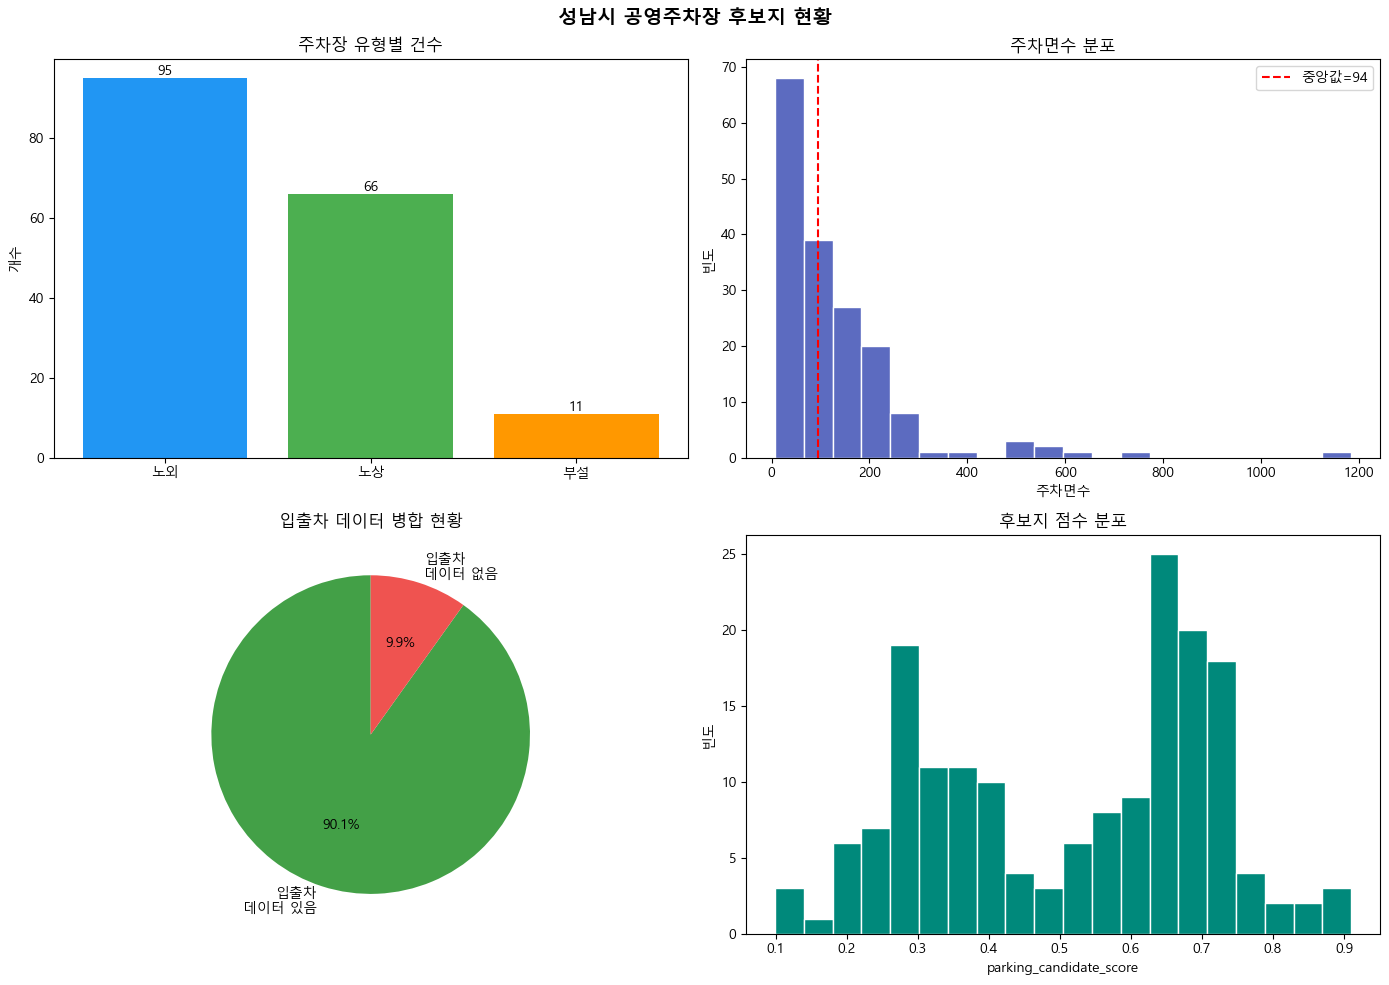

In [13]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('성남시 공영주차장 후보지 현황', fontsize=14, fontweight='bold')

# (1) 주차장유형별 건수
ax = axes[0, 0]
counts = gdf_scored['lot_subtype'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#2196F3', '#4CAF50', '#FF9800'])
ax.bar_label(bars, fmt='%d')
ax.set_title('주차장 유형별 건수')
ax.set_ylabel('개수')

# (2) 주차면수 분포
ax = axes[0, 1]
cap_valid = gdf_scored['capacity_num'].dropna()
ax.hist(cap_valid, bins=20, color='#5C6BC0', edgecolor='white')
ax.axvline(cap_valid.median(), color='red', linestyle='--',
           label=f'중앙값={cap_valid.median():.0f}')
ax.set_title('주차면수 분포')
ax.set_xlabel('주차면수')
ax.set_ylabel('빈도')
ax.legend()

# (3) 입출차 매칭 현황
ax = axes[1, 0]
match_counts = gdf_scored['usage_data_available'].value_counts()
labels = ['입출차\n데이터 있음', '입출차\n데이터 없음']
vals = [match_counts.get(True, 0), match_counts.get(False, 0)]
ax.pie(vals, labels=labels, autopct='%1.1f%%',
       colors=['#43A047', '#EF5350'], startangle=90)
ax.set_title('입출차 데이터 병합 현황')

# (4) 후보지 점수 분포
ax = axes[1, 1]
ax.hist(gdf_scored['parking_candidate_score'], bins=20,
        color='#00897B', edgecolor='white')
ax.set_title('후보지 점수 분포')
ax.set_xlabel('parking_candidate_score')
ax.set_ylabel('빈도')

plt.tight_layout()
plt.show()

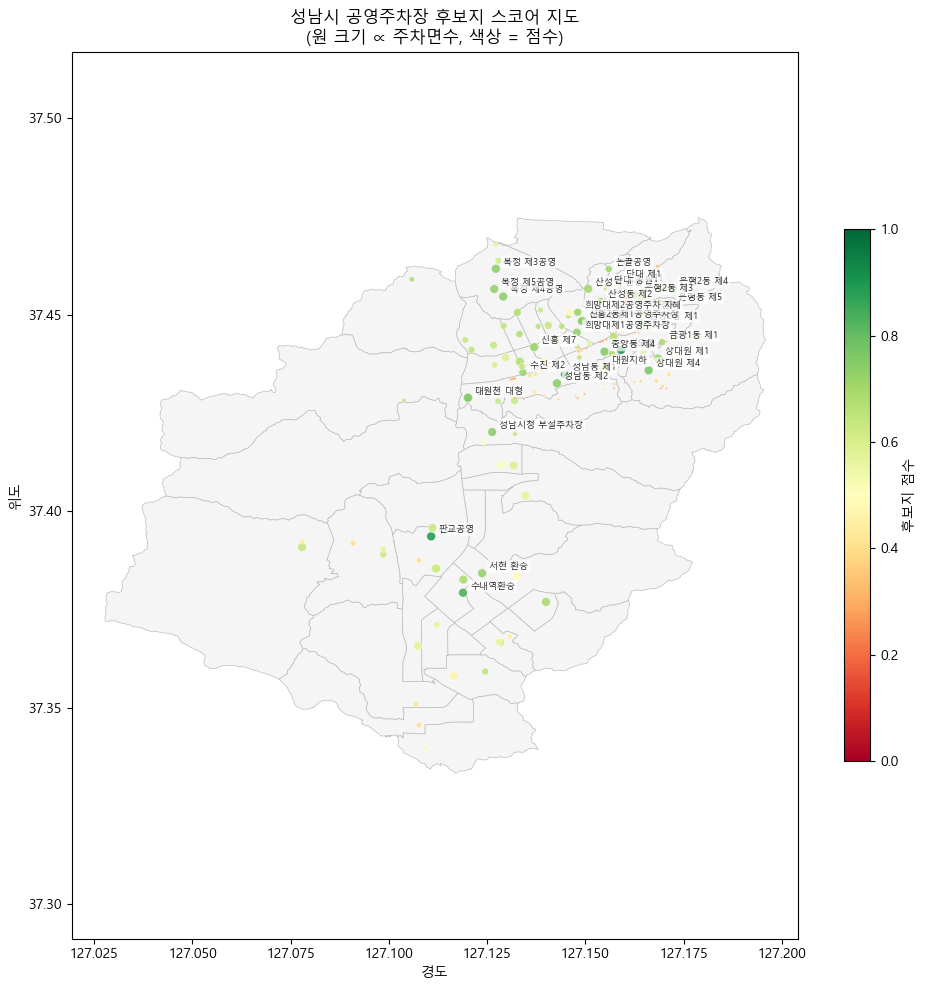

In [14]:
# ── Map: candidates over boundary ────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

boundary_5179 = gpd.read_file(BOUNDARY, layer='dong').to_crs(4326)
boundary_5179.plot(ax=ax, color='#F5F5F5', edgecolor='#BDBDBD', linewidth=0.5)

scatter = gdf_scored.plot(
    ax=ax,
    column='parking_candidate_score',
    cmap='RdYlGn',
    markersize=gdf_scored['capacity_num'].fillna(10).clip(5, 200) / 5,
    legend=True,
    legend_kwds={'label': '후보지 점수', 'shrink': 0.6},
    vmin=0, vmax=1,
    alpha=0.85,
    edgecolors='white',
    linewidths=0.3
)

# Grade A labels
grade_a = gdf_scored[gdf_scored['candidate_grade'] == 'A']
for _, row in grade_a.iterrows():
    ax.annotate(
        row['lot_name'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 3), textcoords='offset points',
        fontsize=6.5, color='#212121',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
    )

ax.set_title('성남시 공영주차장 후보지 스코어 지도\n(원 크기 ∝ 주차면수, 색상 = 점수)', fontsize=12)
ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.axis('equal')
plt.tight_layout()
plt.show()

In [15]:
# ── Top 20 candidate table ────────────────────────────────
DISPLAY_COLS = [
    'candidate_rank', 'candidate_grade', 'lot_name', 'lot_subtype',
    'capacity_num', 'avg_monthly_entries', 'turnover_per_space',
    'parking_candidate_score', 'parking_candidate_score_confidence',
    'candidate_reason'
]
top20 = gdf_scored[DISPLAY_COLS].head(20)
top20 = top20.style.format({
    'capacity_num':                     '{:.0f}',
    'avg_monthly_entries':              '{:.0f}',
    'turnover_per_space':               '{:.1f}',
    'parking_candidate_score':          '{:.3f}',
    'parking_candidate_score_confidence': '{:.2f}',
})
top20

,candidate_rank,candidate_grade,lot_name,lot_subtype,capacity_num,avg_monthly_entries,turnover_per_space,parking_candidate_score,parking_candidate_score_confidence,candidate_reason
0,1,A,해오름,노외,531,5591,10.5,0.910,1.00,"노외 공영주차장, 주차면수 큼, 면당 입출차 중간, 24시간 운영"
1,2,A,판교공영,노외,734,24861,33.9,0.897,1.00,"노외 공영주차장, 주차면수 큼, 면당 입출차 높음, 24시간 운영"
2,3,A,성남동 대형,노외,565,13989,24.8,0.884,1.00,"노외 공영주차장, 주차면수 큼, 면당 입출차 중간, 24시간 운영"
3,4,A,성남동 제1,노외,388,984,2.5,0.856,1.00,"노외 공영주차장, 주차면수 큼, 면당 입출차 낮음, 24시간 운영"
4,5,A,수내역환승,노외,526,17424,33.1,0.836,1.00,"노외 공영주차장, 주차면수 큼, 면당 입출차 높음, 24시간 운영"
5,6,A,모란공영,노외,603,nan,nan,0.804,0.60,"노외 공영주차장, 주차면수 큼, 입출차 데이터 없음, 24시간 운영"
6,7,A,은행동 제5,노외,292,1998,6.8,0.790,1.00,"노외 공영주차장, 주차면수 큼, 면당 입출차 낮음, 24시간 운영"
7,8,A,상대원 제4,노외,283,2727,9.6,0.776,1.00,"노외 공영주차장, 주차면수 큼, 면당 입출차 낮음, 24시간 운영"
8,9,A,은행2동 제4,노외,230,237,1.0,0.773,1.00,"노외 공영주차장, 주차면수 큼, 면당 입출차 낮음, 24시간 운영"
9,10,A,중앙동 제4,노외,239,1952,8.2,0.756,1.00,"노외 공영주차장, 주차면수 큼, 면당 입출차 낮음, 24시간 운영"


In [16]:
# ── Optional folium map ───────────────────────────────────
try:
    import folium
    from folium.plugins import MarkerCluster

    center_lat = gdf_scored['lat'].mean()
    center_lon = gdf_scored['lon'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=13,
                   tiles='CartoDB positron')

    score_min = gdf_scored['parking_candidate_score'].min()
    score_max = gdf_scored['parking_candidate_score'].max()

    def score_to_color(score):
        norm = (score - score_min) / (score_max - score_min + 1e-9)
        if norm >= 0.75: return '#1B5E20'
        if norm >= 0.50: return '#43A047'
        if norm >= 0.25: return '#FFA726'
        return '#E53935'

    for _, row in gdf_scored.iterrows():
        popup_html = f"""
        <b>{row['lot_name']}</b><br>
        유형: {row['lot_subtype']} | 등급: {row['candidate_grade']}<br>
        주차면수: {int(row['capacity_num']) if pd.notna(row['capacity_num']) else '정보없음'}<br>
        월평균 입출차: {int(row['avg_monthly_entries']) if pd.notna(row.get('avg_monthly_entries')) else '데이터없음'}<br>
        면당 회전율: {f"{row['turnover_per_space']:.1f}" if pd.notna(row.get('turnover_per_space')) else '데이터없음'}<br>
        <b>점수: {row['parking_candidate_score']:.3f}</b><br>
        {row['candidate_reason']}
        """
        radius = max(5, min(15, (row['capacity_num'] or 10) / 20))
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=radius,
            color=score_to_color(row['parking_candidate_score']),
            fill=True, fill_opacity=0.75,
            popup=folium.Popup(popup_html, max_width=250),
            tooltip=f"{row['lot_name']} ({row['candidate_grade']})"
        ).add_to(m)

    map_path = PROC / 'parking_candidates_map.html'
    m.save(str(map_path))
    print('Folium 지도 저장:', map_path)

except ImportError:
    print('folium 미설치 — 지도 파일 생략')

Folium 지도 저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\parking_candidates_map.html


## 8. 최종 내보내기

In [17]:
# ── Column cleanup before export ──────────────────────────
DROP_INTERNAL = ['valid_coords', 'within_boundary', 'lot_name_norm']
gdf_export = gdf_scored.drop(
    columns=[c for c in DROP_INTERNAL if c in gdf_scored.columns]
).copy()

print(f'내보내기 컬럼 ({len(gdf_export.columns)}개):', list(gdf_export.columns))
print(f'내보내기 행수: {len(gdf_export):,}')

# ── GeoPackage ────────────────────────────────────────────
gpkg_path = PROC / 'parking_candidates.gpkg'
gdf_export.to_file(gpkg_path, driver='GPKG', layer='parking_candidates')
print('GeoPackage 저장:', gpkg_path)

# ── Parquet (drop geometry for pure parquet) ──────────────
parq_path = PROC / 'parking_candidates.parquet'
df_parq = gdf_export.drop(columns='geometry').copy()
df_parq.to_parquet(parq_path, index=False)
print('Parquet 저장:', parq_path)

내보내기 컬럼 (39개): ['lot_id', 'lot_name', 'lot_class', 'lot_subtype', 'address_road', 'address_jibun', 'capacity_raw', 'op_days', 'op_wday_start', 'op_wday_end', 'op_sat_start', 'op_sat_end', 'op_hol_start', 'op_hol_end', 'fee_info', 'operator', 'lat', 'lon', 'has_disabled_spaces', 'data_date', 'geometry', 'valid_month_count', 'avg_monthly_entries', 'total_valid_entries', 'usage_data_available', 'capacity_num', 'capacity_score', 'turnover_per_space', 'availability_score', 'usage_confidence', 'subtype_score', 'op_hours', 'operation_score', 'parking_candidate_score', 'parking_candidate_score_confidence', 'candidate_rank', 'candidate_grade', 'candidate_reason', 'risk_note']
내보내기 행수: 172
GeoPackage 저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\parking_candidates.gpkg
Parquet 저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\parking_candidates.parquet


In [18]:
# ── Final summary ─────────────────────────────────────────
print('=' * 55)
print('NB06 완료 요약')
print('=' * 55)
print(f'최종 후보지 수:       {len(gdf_export):>5,}개')
print(f'입출차 병합 성공:     {gdf_export["usage_data_available"].sum():>5,}개 '
      f'({gdf_export["usage_data_available"].mean():.1%})')
print(f'평균 후보지 점수:     {gdf_export["parking_candidate_score"].mean():>8.3f}')
print()
print('등급 분포:')
for g, cnt in gdf_export['candidate_grade'].value_counts().sort_index().items():
    print(f'  {g}등급: {cnt}개')
print()
print('Top 10 후보지:')
top10 = gdf_export[['candidate_rank', 'lot_name', 'lot_subtype',
                     'capacity_num', 'turnover_per_space',
                     'parking_candidate_score', 'candidate_grade',
                     'candidate_reason']].head(10)
print(top10.to_string(index=False))

NB06 완료 요약
최종 후보지 수:         172개
입출차 병합 성공:       155개 (90.1%)
평균 후보지 점수:        0.516

등급 분포:
  A등급: 34개
  B등급: 52개
  C등급: 51개
  D등급: 35개

Top 10 후보지:
 candidate_rank lot_name lot_subtype  capacity_num  turnover_per_space  parking_candidate_score candidate_grade                      candidate_reason
              1      해오름          노외           531           10.528437                   0.9101               A  노외 공영주차장, 주차면수 큼, 면당 입출차 중간, 24시간 운영
              2     판교공영          노외           734           33.870300                   0.8974               A  노외 공영주차장, 주차면수 큼, 면당 입출차 높음, 24시간 운영
              3   성남동 대형          노외           565           24.758483                   0.8841               A  노외 공영주차장, 주차면수 큼, 면당 입출차 중간, 24시간 운영
              4   성남동 제1          노외           388            2.536512                   0.8563               A  노외 공영주차장, 주차면수 큼, 면당 입출차 낮음, 24시간 운영
              5    수내역환승          노외           526           33.125964                   0.8361  